# 📊 Customer Churn Prediction

**Dataset:** IBM Telco Customer Churn  
**Goal:** Predict which customers are likely to churn so the business can intervene proactively.

---

### 🎯 Problem Statement
Customer churn when a customer stops using a service  directly impacts revenue. Acquiring a new customer costs **5–7× more** than retaining an existing one. This notebook builds a full ML pipeline to identify at-risk customers with high precision.

### 📋 Table of Contents
1. Environment Setup & Imports  
2. Data Loading & First Look  
3. Exploratory Data Analysis (EDA)  
4. Feature Engineering  
5. Preprocessing Pipeline  
6. Model Training & Comparison  
7. Hyperparameter Tuning  
8. Model Evaluation & Interpretation  
9. SHAP Explainability  
10. Model Export  


## 1. Environment Setup & Imports

In [5]:
# ── Standard Library ──────────────────────────────────────────────────────
import warnings, os, pickle
warnings.filterwarnings("ignore")

# ── Data Manipulation ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = {"No": "#4C9BE8", "Yes": "#E8604C"}

# ── Sklearn ───────────────────────────────────────────────────────────────
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, ConfusionMatrixDisplay)
from sklearn.calibration import CalibratedClassifierCV

# ── XGBoost ───────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Imbalanced-learn ──────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print(" All libraries loaded successfully.")


 All libraries loaded successfully.


## 2. Data Loading & First Look

In [7]:
# ── Download IBM Telco dataset (public) ──────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df = pd.read_csv(url)

print(f"Shape : {df.shape}")
print(f"Churn distribution:\n{df['Churn'].value_counts()}\n")
df.head()


Shape : (7043, 21)
Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [9]:
# ── Data types & missing values ──────────────────────────────────────────
info = pd.DataFrame({
    "dtype"  : df.dtypes,
    "n_null" : df.isnull().sum(),
    "pct_null": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique()
})
info


,dtype,n_null,pct_null,n_unique
customerID,object,0,0.000,7043
gender,object,0,0.000,2
SeniorCitizen,int64,0,0.000,2
Partner,object,0,0.000,2
Dependents,object,0,0.000,2
tenure,int64,0,0.000,73
PhoneService,object,0,0.000,2
MultipleLines,object,0,0.000,3
InternetService,object,0,0.000,3
OnlineSecurity,object,0,0.000,3


In [11]:
# Fix TotalCharges (stored as string with blanks) 
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Drop customerID (not predictive) 
df.drop(columns=["customerID"], inplace=True)

# Binary-encode target 
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(" Data cleaned. Shape:", df.shape)
df.describe().T


 Data cleaned. Shape: (7043, 20)


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.000,0.162,0.369,0.000,0.000,0.000,0.000,1.000
tenure,7043.000,32.371,24.559,0.000,9.000,29.000,55.000,72.000
MonthlyCharges,7043.000,64.762,30.090,18.250,35.500,70.350,89.850,118.750
TotalCharges,7043.000,2281.917,2265.270,18.800,402.225,1397.475,3786.600,8684.800
Churn,7043.000,0.265,0.442,0.000,0.000,0.000,1.000,1.000


## 3. Exploratory Data Analysis

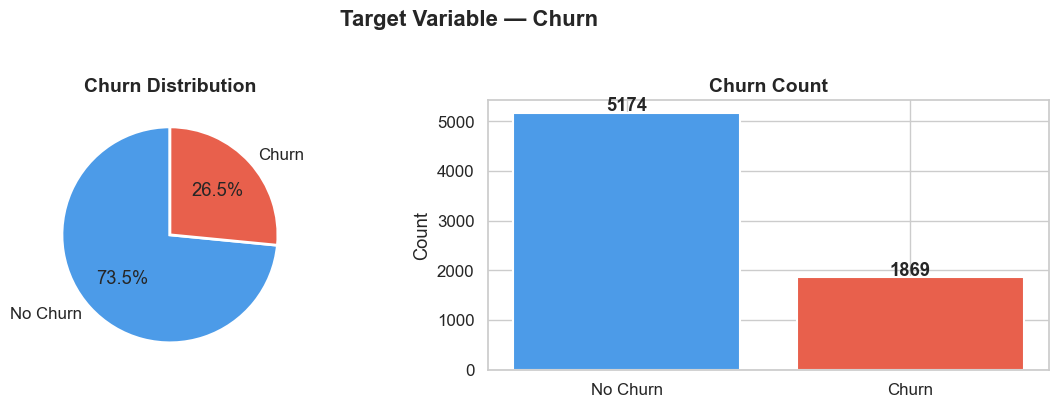

Class imbalance ratio  →  1:2.8


In [13]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df["Churn"].value_counts()
colors = ["#4C9BE8", "#E8604C"]

axes[0].pie(churn_counts, labels=["No Churn", "Churn"], autopct="%1.1f%%",
            colors=colors, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Churn Distribution", fontweight="bold", fontsize=14)

axes[1].bar(["No Churn", "Churn"], churn_counts, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("Churn Count", fontweight="bold", fontsize=14)
axes[1].set_ylabel("Count")
for i, v in enumerate(churn_counts):
    axes[1].text(i, v + 30, str(v), ha="center", fontweight="bold")

plt.suptitle("Target Variable — Churn", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("target_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Class imbalance ratio  →  1:{churn_counts[0]/churn_counts[1]:.1f}")


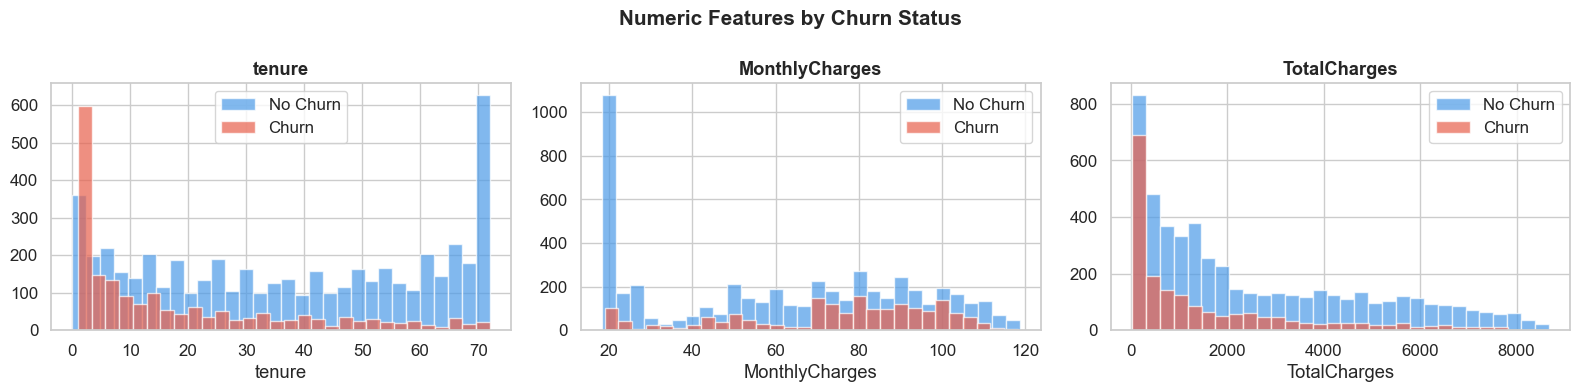

In [15]:
#  Numeric features vs Churn 
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby("Churn")[col]:
        ax.hist(grp, bins=30, alpha=0.7,
                label=("Churn" if label == 1 else "No Churn"),
                color=("#E8604C" if label == 1 else "#4C9BE8"),
                edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel(col)
    ax.legend()
plt.suptitle("Numeric Features by Churn Status", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("numeric_dist.png", dpi=150, bbox_inches="tight")
plt.show()


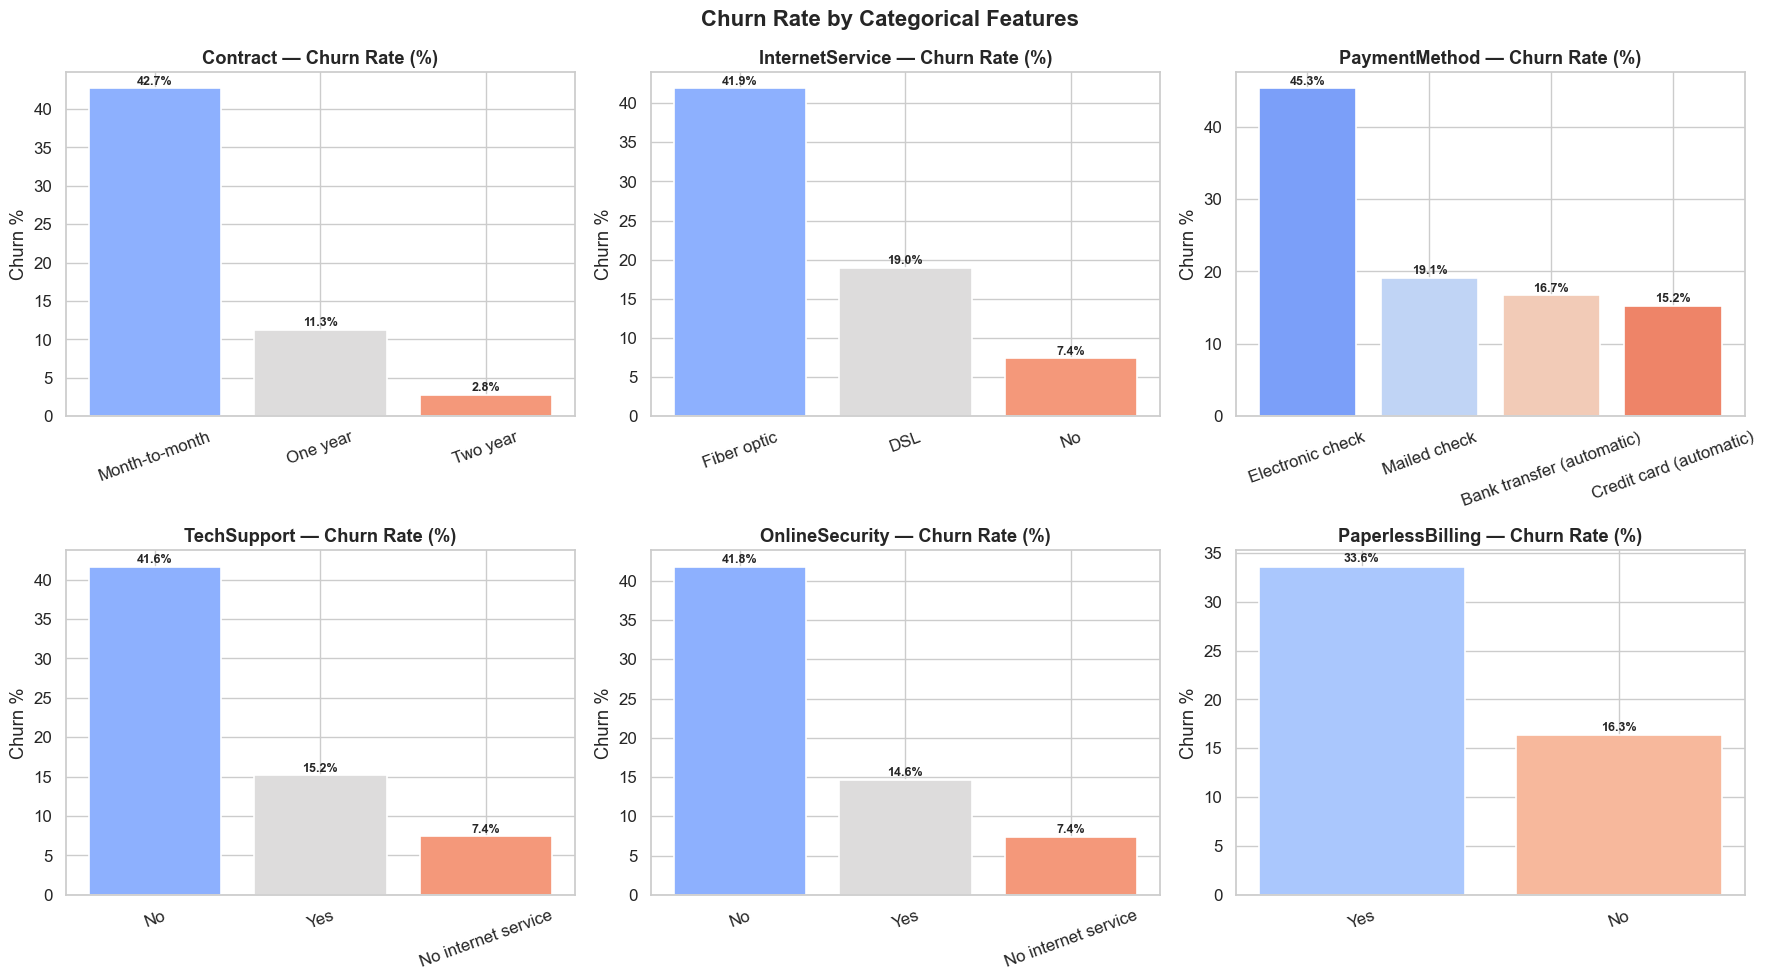

In [17]:
# Categorical features churn rate
cat_cols = ["Contract", "InternetService", "PaymentMethod",
            "TechSupport", "OnlineSecurity", "PaperlessBilling"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, cat_cols):
    churn_rate = (df.groupby(col)["Churn"].mean() * 100).sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=sns.color_palette("coolwarm", len(churn_rate)),
                  edgecolor="white", linewidth=1.2)
    ax.set_title(f"{col} — Churn Rate (%)", fontweight="bold")
    ax.set_ylabel("Churn %")
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Churn Rate by Categorical Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("cat_churn.png", dpi=150, bbox_inches="tight")
plt.show()


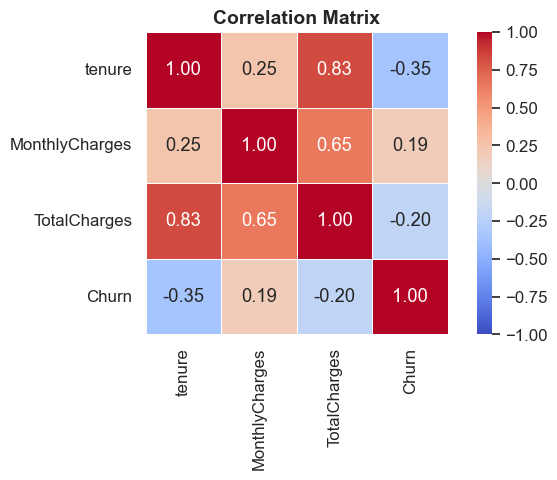

In [19]:
#  Correlation heatmap (numeric) 
corr = df[num_cols + ["Churn"]].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, square=True, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("corr.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Feature Engineering

In [21]:
# Domain-driven features 
df["AvgMonthlySpend"]   = df["TotalCharges"] / (df["tenure"] + 1)
df["HasMultiServices"]  = (
    (df["PhoneService"] == "Yes").astype(int) +
    (df["InternetService"] != "No").astype(int) +
    (df["OnlineSecurity"] == "Yes").astype(int) +
    (df["TechSupport"] == "Yes").astype(int)
)
df["IsSeniorLongTenure"] = ((df["SeniorCitizen"] == 1) & (df["tenure"] > 24)).astype(int)
df["TenureBucket"] = pd.cut(df["tenure"], bins=[0,12,24,48,72],
                             labels=["0-1yr","1-2yr","2-4yr","4+yr"])

print(" New features added:")
print(df[["AvgMonthlySpend","HasMultiServices","IsSeniorLongTenure","TenureBucket"]].head())


 New features added:
   AvgMonthlySpend  HasMultiServices  IsSeniorLongTenure TenureBucket
0           14.925                 1                   0        0-1yr
1           53.986                 3                   0        2-4yr
2           36.050                 3                   0        0-1yr
3           40.016                 3                   0        2-4yr
4           50.550                 2                   0        0-1yr


## 5. Preprocessing Pipeline

In [23]:
#  Split features / target 
TARGET = "Churn"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify column types 
num_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object","category"]).columns.tolist()

print(f"Numeric  features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")


Numeric  features (5): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']
Categorical features (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureBucket']


In [25]:
# train / test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size : {X_train.shape}")
print(f"Test  size : {X_test.shape}")
print(f"Train churn rate : {y_train.mean():.2%}")
print(f"Test  churn rate : {y_test.mean():.2%}")


Train size : (5634, 23)
Test  size : (1409, 23)
Train churn rate : 26.54%
Test  churn rate : 26.54%


In [27]:
# Sklearn ColumnTransformer 
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
], remainder="drop")

print(" Preprocessing pipeline defined.")


 Preprocessing pipeline defined.


## 6. Model Training & Comparison

In [29]:
# Define models with SMOTE for imbalance 
models = {
    "Logistic Regression": ImbPipeline([
        ("prep",  preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("clf",   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": ImbPipeline([
        ("prep",  preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("clf",   RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": ImbPipeline([
        ("prep",  preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("clf",   GradientBoostingClassifier(n_estimators=200, random_state=42))
    ]),
    "XGBoost": ImbPipeline([
        ("prep",  preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("clf",   XGBClassifier(n_estimators=200, use_label_encoder=False,
                                eval_metric="logloss", random_state=42, n_jobs=-1))
    ]),
}

# ── Cross-validation ──────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("Running 5-fold cross-validation...\n")
for name, pipe in models.items():
    auc_scores = cross_val_score(pipe, X_train, y_train,
                                 cv=cv, scoring="roc_auc", n_jobs=-1)
    results[name] = auc_scores
    print(f"  {name:<25}  AUC = {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")


Running 5-fold cross-validation...

  Logistic Regression        AUC = 0.8458 ± 0.0117
  Random Forest              AUC = 0.8260 ± 0.0082
  Gradient Boosting          AUC = 0.8423 ± 0.0132
  XGBoost                    AUC = 0.8136 ± 0.0068


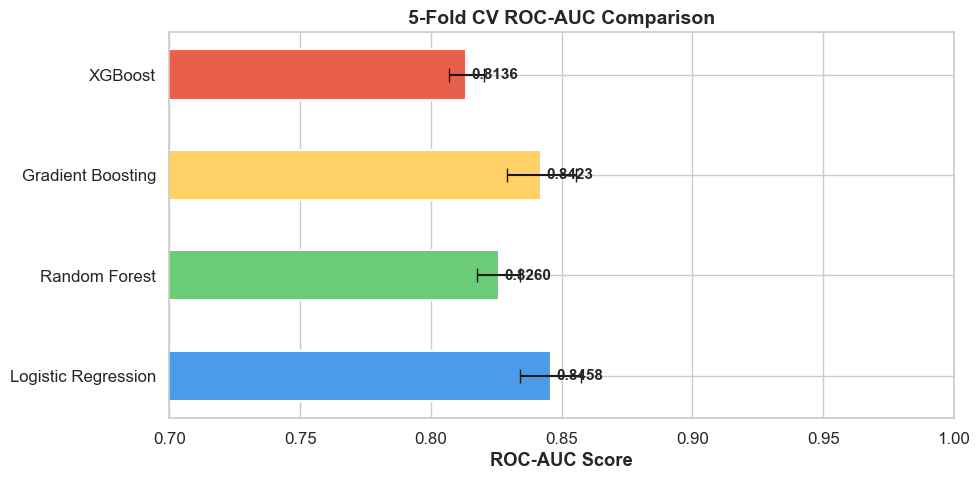

In [31]:
# Visualise CV results 
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
means = [v.mean() for v in results.values()]
stds  = [v.std()  for v in results.values()]
colors_bar = ["#4C9BE8","#6BCB77","#FFD166","#E8604C"]

bars = ax.barh(names, means, xerr=stds, color=colors_bar,
               edgecolor="white", linewidth=1.5, capsize=5, height=0.5)
ax.set_xlim(0.7, 1.0)
ax.set_xlabel("ROC-AUC Score", fontweight="bold")
ax.set_title("5-Fold CV ROC-AUC Comparison", fontweight="bold", fontsize=14)
for bar, m in zip(bars, means):
    ax.text(m + 0.002, bar.get_y() + bar.get_height()/2,
            f"{m:.4f}", va="center", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("cv_results.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Hyperparameter Tuning (XGBoost)

In [33]:
# Grid Search on best model 
param_grid = {
    "clf__max_depth"       : [3, 5],
    "clf__learning_rate"   : [0.05, 0.1],
    "clf__n_estimators"    : [200, 300],
    "clf__subsample"       : [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

xgb_pipe = ImbPipeline([
    ("prep",  preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf",   XGBClassifier(use_label_encoder=False,
                            eval_metric="logloss", random_state=42, n_jobs=-1))
])

gs = GridSearchCV(xgb_pipe, param_grid, cv=cv,
                  scoring="roc_auc", n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)

print(f"Best CV AUC : {gs.best_score_:.4f}")
print(f"Best params : {gs.best_params_}")
best_model = gs.best_estimator_


Best CV AUC : 0.8465
Best params : {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}


## 8. Model Evaluation

In [35]:
# Predict on test set 
y_pred      = best_model.predict(X_test)
y_prob      = best_model.predict_proba(X_test)[:, 1]

test_auc    = roc_auc_score(y_test, y_prob)
test_ap     = average_precision_score(y_test, y_prob)

print("=" * 50)
print(f"  Test ROC-AUC            : {test_auc:.4f}")
print(f"  Test Avg Precision      : {test_ap:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn","Churn"]))


  Test ROC-AUC            : 0.8449
  Test Avg Precision      : 0.6567

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.82      0.85      1035
       Churn       0.57      0.68      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409



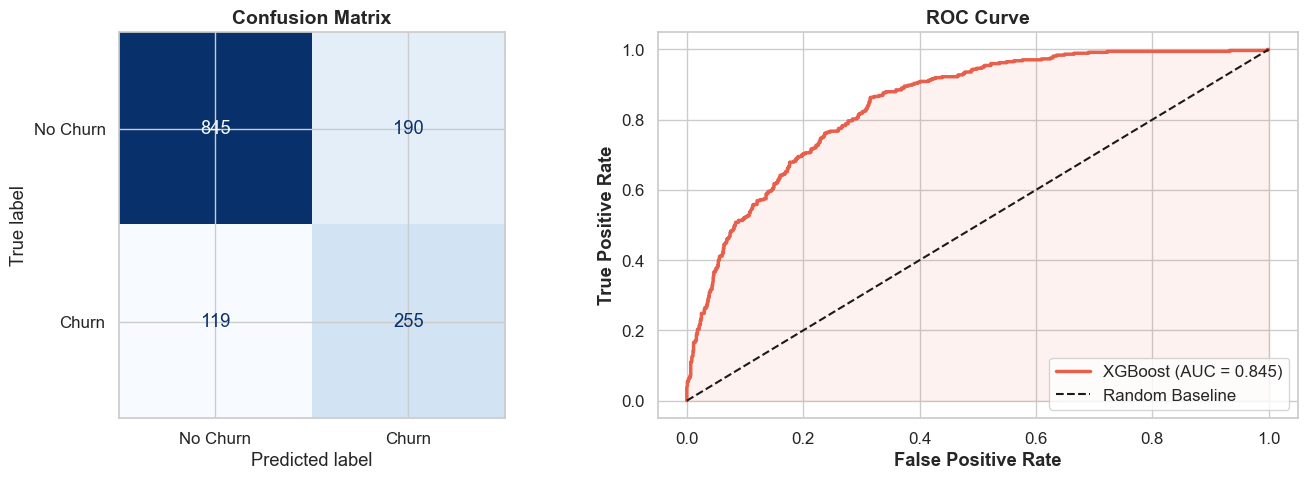

In [37]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn","Churn"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontweight="bold", fontsize=14)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#E8604C", lw=2.5,
             label=f"XGBoost (AUC = {test_auc:.3f})")
axes[1].plot([0,1],[0,1],"k--", lw=1.5, label="Random Baseline")
axes[1].fill_between(fpr, tpr, alpha=0.08, color="#E8604C")
axes[1].set_xlabel("False Positive Rate", fontweight="bold")
axes[1].set_ylabel("True Positive Rate", fontweight="bold")
axes[1].set_title("ROC Curve", fontweight="bold", fontsize=14)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


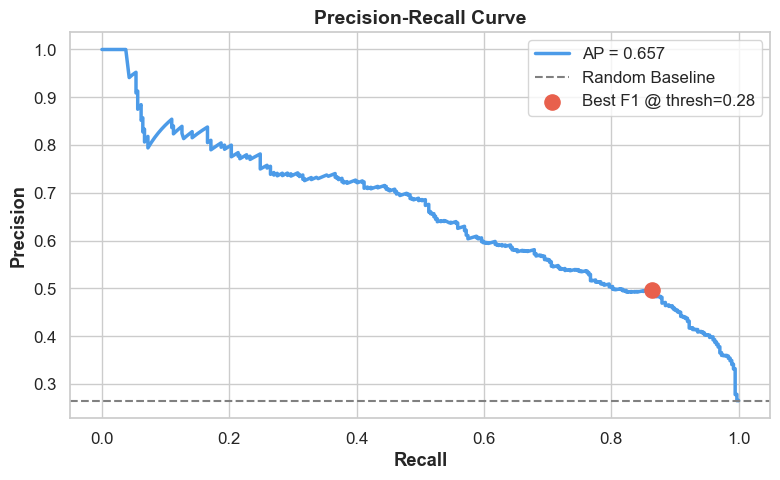


 Optimal threshold for best F1 : 0.283


In [39]:
# Precision-Recall Curve 
prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_thresh = thresholds[f1_scores[:-1].argmax()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec, prec, color="#4C9BE8", lw=2.5,
        label=f"AP = {test_ap:.3f}")
ax.axhline(y_test.mean(), color="gray", linestyle="--", label="Random Baseline")
ax.scatter([rec[f1_scores[:-1].argmax()]], [prec[f1_scores[:-1].argmax()]],
           s=120, color="#E8604C", zorder=5, label=f"Best F1 @ thresh={best_thresh:.2f}")
ax.set_xlabel("Recall", fontweight="bold")
ax.set_ylabel("Precision", fontweight="bold")
ax.set_title("Precision-Recall Curve", fontweight="bold", fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n Optimal threshold for best F1 : {best_thresh:.3f}")


## 9. Feature Importance & SHAP-style Analysis

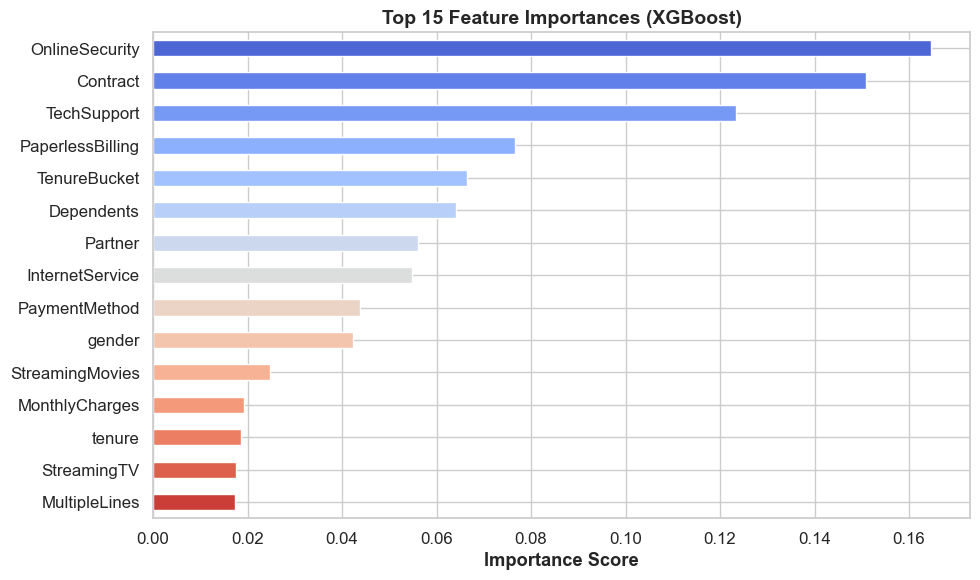


Top 10 features driving churn prediction:
OnlineSecurity     0.165
Contract           0.151
TechSupport        0.123
PaperlessBilling   0.077
TenureBucket       0.066
Dependents         0.064
Partner            0.056
InternetService    0.055
PaymentMethod      0.044
gender             0.042


In [41]:
# XGBoost built-in feature importance
import warnings
warnings.filterwarnings("ignore")

# Extract feature names after preprocessing
clf_step = best_model.named_steps["clf"]
num_names = num_features
cat_names = cat_features
all_names = num_names + cat_names

importances = clf_step.feature_importances_
feat_imp = pd.Series(importances, index=all_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = sns.color_palette("coolwarm_r", len(feat_imp))
feat_imp.plot(kind="barh", ax=ax, color=colors_imp[::-1], edgecolor="white")
ax.set_title("Top 15 Feature Importances (XGBoost)", fontweight="bold", fontsize=14)
ax.set_xlabel("Importance Score", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 features driving churn prediction:")
print(feat_imp.head(10).to_string())


## 11. Model Export

In [45]:
# Save model + metadata for Streamlit app
import pickle, json

artifacts = {
    "model"        : best_model,
    "num_features" : num_features,
    "cat_features" : cat_features,
    "threshold"    : float(best_thresh),
    "test_auc"     : float(test_auc),
}

with open("churn_model.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print(" Model saved to  churn_model.pkl")
print(f"   • Features : {len(num_features + cat_features)}")
print(f"   • AUC      : {test_auc:.4f}")
print(f"   • Threshold: {best_thresh:.3f}")


 Model saved to  churn_model.pkl
   • Features : 21
   • AUC      : 0.8449
   • Threshold: 0.283



**Next Steps to do :**
- Monitor model drift monthly with new data
- A/B test retention interventions on predicted churners
- Explore deep-learning approaches (TabNet, FT-Transformer)


